In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Cài đặt theme chung cho biểu đồ
sns.set_theme(style="whitegrid")

# Đọc dữ liệu
df = pd.read_csv('diabetes.csv')

# Hiển thị 5 dòng đầu tiên để kiểm tra
display(df.head())

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


=== THỐNG KÊ DỮ LIỆU THIẾU TRƯỚC KHI XỬ LÝ ===
chol          1
hdl           1
ratio         1
glyhb        13
height        5
weight        1
frame        12
bp.1s         5
bp.1d         5
bp.2s       262
bp.2d       262
waist         2
hip           2
time.ppn      3
dtype: int64


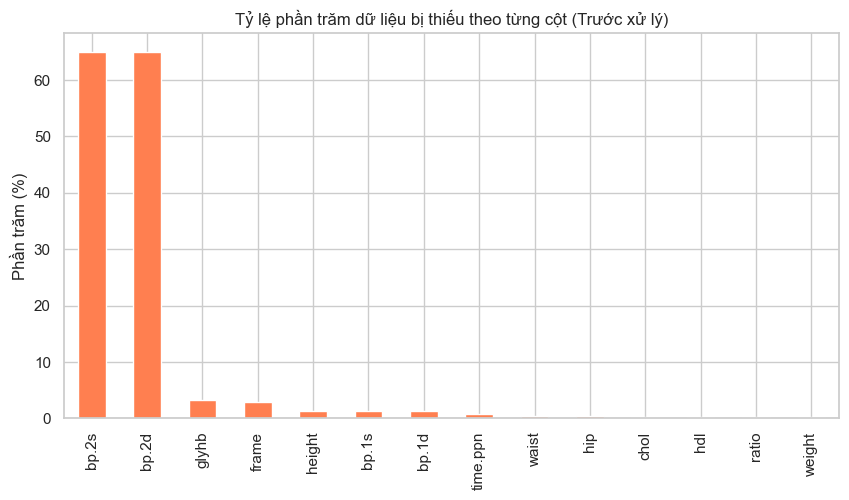

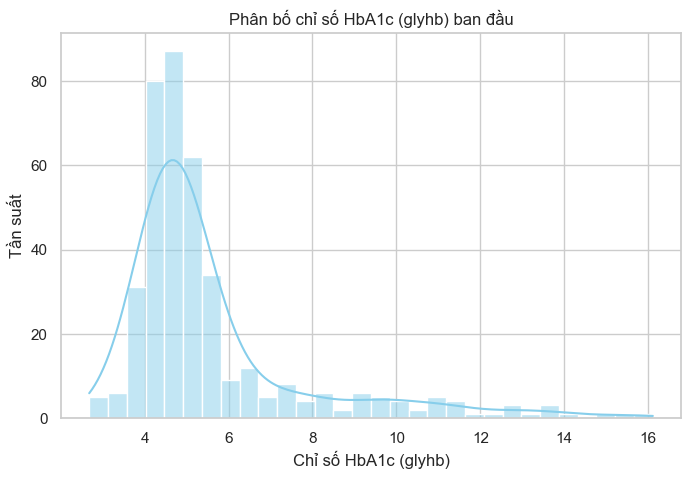

In [8]:
# 1. Thống kê số lượng dữ liệu bị thiếu ở mỗi cột
print("=== THỐNG KÊ DỮ LIỆU THIẾU TRƯỚC KHI XỬ LÝ ===")
missing_data_before = df.isnull().sum()
print(missing_data_before[missing_data_before > 0])

# 2. Trực quan hóa phần trăm dữ liệu bị thiếu bằng biểu đồ thanh (Bar chart)
plt.figure(figsize=(10, 5))
missing_percentage = (missing_data_before[missing_data_before > 0] / len(df)) * 100
missing_percentage.sort_values(ascending=False).plot(kind='bar', color='coral')
plt.title('Tỷ lệ phần trăm dữ liệu bị thiếu theo từng cột (Trước xử lý)')
plt.ylabel('Phần trăm (%)')
plt.show()

# 3. Trực quan hóa phân bố của chỉ số HbA1c (glyhb) ban đầu
plt.figure(figsize=(8, 5))
sns.histplot(df['glyhb'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Phân bố chỉ số HbA1c (glyhb) ban đầu')
plt.xlabel('Chỉ số HbA1c (glyhb)')
plt.ylabel('Tần suất')
plt.show()

In [9]:
# Tạo một bản sao để làm sạch
df_clean = df.copy()

# 1. Loại bỏ các cột thừa và thiếu quá nhiều dữ liệu
df_clean = df_clean.drop(columns=['id', 'bp.2s', 'bp.2d'])

# 2. Loại bỏ các dòng bị thiếu giá trị mục tiêu (glyhb)
df_clean = df_clean.dropna(subset=['glyhb'])

# 3. Điền các giá trị thiếu còn lại
num_cols = df_clean.select_dtypes(include=np.number).columns
cat_cols = df_clean.select_dtypes(exclude=np.number).columns

# Điền trung vị cho cột số và mode cho cột phân loại
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# 4. Tạo đặc trưng mới
# Tính chỉ số BMI
df_clean['BMI'] = (df_clean['weight'] / (df_clean['height']**2)) * 703

# Hàm phân loại tiểu đường
def categorize_diabetes(glyhb):
    if glyhb >= 6.5: return 'Diabetes'
    elif glyhb >= 5.7: return 'Prediabetes'
    else: return 'Normal'

df_clean['diabetes_status'] = df_clean['glyhb'].apply(categorize_diabetes)

# 5. Xuất dữ liệu đã làm sạch
df_clean.to_csv('Diab_pyth_data_clean.csv', index=False)
print("=== HOÀN TẤT LÀM SẠCH VÀ LƯU FILE 'Diab_pyth_data_clean.csv' ===")

=== HOÀN TẤT LÀM SẠCH VÀ LƯU FILE 'Diab_pyth_data_clean.csv' ===


=== KIỂM TRA DỮ LIỆU THIẾU SAU KHI XỬ LÝ ===
0 giá trị thiếu còn lại.


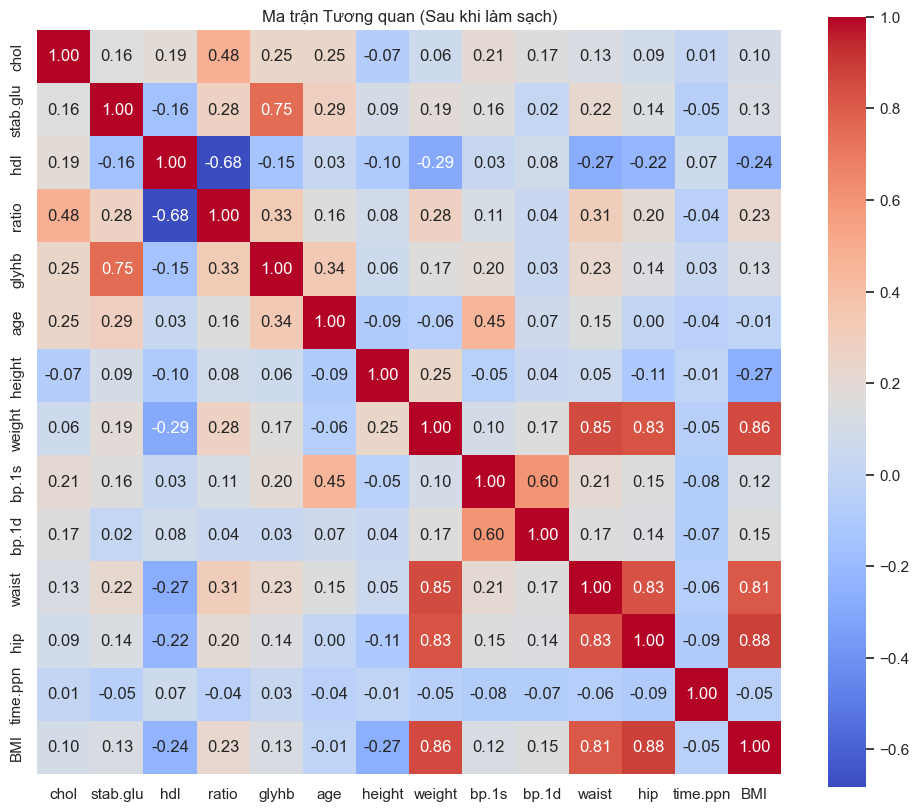

C:\Users\USER\AppData\Local\Temp\ipykernel_23732\468258622.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='diabetes_status', order=['Normal', 'Prediabetes', 'Diabetes'], palette='viridis')


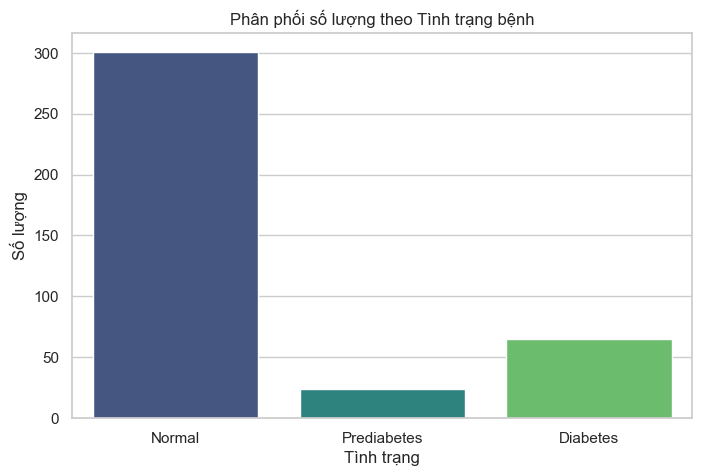

C:\Users\USER\AppData\Local\Temp\ipykernel_23732\468258622.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='diabetes_status', y='stab.glu', order=['Normal', 'Prediabetes', 'Diabetes'], palette='Set2')


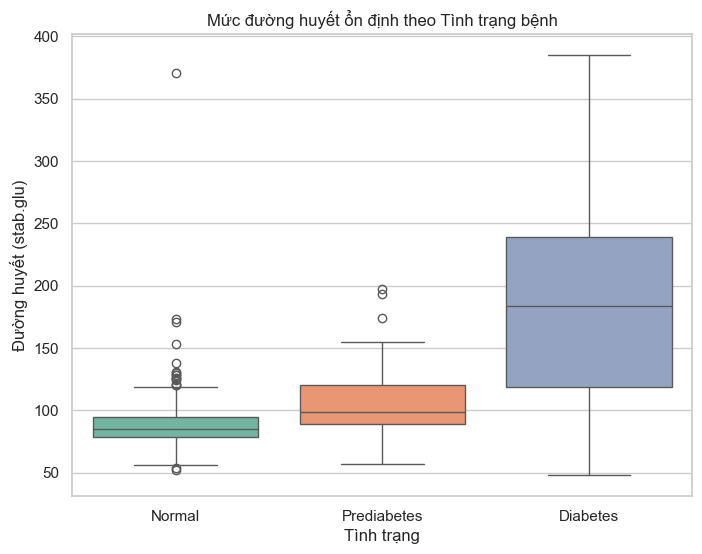

In [10]:
# 1. Kiểm tra lại dữ liệu thiếu
print("=== KIỂM TRA DỮ LIỆU THIẾU SAU KHI XỬ LÝ ===")
print(df_clean.isnull().sum().sum(), "giá trị thiếu còn lại.")

# 2. Biểu đồ Heatmap thể hiện tương quan giữa các biến số sau khi làm sạch
plt.figure(figsize=(12, 10))
corr_clean = df_clean.select_dtypes(include=np.number).corr()
sns.heatmap(corr_clean, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Ma trận Tương quan (Sau khi làm sạch)')
plt.show()

# 3. Phân phối tình trạng tiểu đường (Cột mới tạo)
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='diabetes_status', order=['Normal', 'Prediabetes', 'Diabetes'], palette='viridis')
plt.title('Phân phối số lượng theo Tình trạng bệnh')
plt.xlabel('Tình trạng')
plt.ylabel('Số lượng')
plt.show()

# 4. Tương quan giữa Đường huyết ổn định (stab.glu) và Tình trạng bệnh
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='diabetes_status', y='stab.glu', order=['Normal', 'Prediabetes', 'Diabetes'], palette='Set2')
plt.title('Mức đường huyết ổn định theo Tình trạng bệnh')
plt.xlabel('Tình trạng')
plt.ylabel('Đường huyết (stab.glu)')
plt.show()